# Rep. 4. Checkpoint 3. Estrategias II
 
Dayanni Godoy Rosales

Eduardo Veytia Hernández 

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import yfinance as yf

In [2]:
VENCIMIENTO = '2026-04-17'

spy = yf.Ticker('SPY')

# Precio actual del subyacente
hist = spy.history(period='1d')
S0 = round(hist['Close'].iloc[-1], 2)
print(f'Precio actual de SPY (S0): ${S0}')

# Cadena de opciones
chain = spy.option_chain(VENCIMIENTO)
calls = chain.calls.copy()
puts  = chain.puts.copy()

# Precio mid = promedio entre bid y ask
calls['mid'] = (calls['bid'] + calls['ask']) / 2
puts['mid']  = (puts['bid']  + puts['ask'])  / 2

print(f'\nVencimiento: {VENCIMIENTO}')
print(f'Número de strikes disponibles (calls): {len(calls)}')
print(f'Número de strikes disponibles (puts):  {len(puts)}')

# Mostrar las opciones más cercanas al precio actual
rango = 60  # ±60 dólares alrededor de S0
print(f'\n--- CALLS cercanos a S0 (±${rango}) ---')
display(calls[(calls['strike'] >= S0 - rango) & (calls['strike'] <= S0 + rango)]
        [['strike', 'bid', 'ask', 'mid', 'impliedVolatility']]
        .rename(columns={'impliedVolatility': 'IV'})
        .set_index('strike')
        .style.format({'bid': '${:.2f}', 'ask': '${:.2f}', 'mid': '${:.2f}', 'IV': '{:.1%}'}))

print(f'\n--- PUTS cercanos a S0 (±${rango}) ---')
display(puts[(puts['strike'] >= S0 - rango) & (puts['strike'] <= S0 + rango)]
        [['strike', 'bid', 'ask', 'mid', 'impliedVolatility']]
        .rename(columns={'impliedVolatility': 'IV'})
        .set_index('strike')
        .style.format({'bid': '${:.2f}', 'ask': '${:.2f}', 'mid': '${:.2f}', 'IV': '{:.1%}'}))

Precio actual de SPY (S0): $679.91

Vencimiento: 2026-04-17
Número de strikes disponibles (calls): 249
Número de strikes disponibles (puts):  224

--- CALLS cercanos a S0 (±$60) ---


,bid,ask,mid,IV
strike,,,,
620.000000,$60.08,$60.49,$60.28,33.9%
621.000000,$59.10,$59.51,$59.30,33.6%
622.000000,$58.09,$58.50,$58.30,33.0%
623.000000,$55.92,$58.73,$57.33,41.8%
624.000000,$54.93,$57.74,$56.34,41.3%
625.000000,$55.11,$55.53,$55.32,31.8%
626.000000,$54.12,$54.53,$54.33,31.3%
627.000000,$51.95,$54.77,$53.36,39.7%
628.000000,$52.14,$52.55,$52.34,30.6%



--- PUTS cercanos a S0 (±$60) ---


,bid,ask,mid,IV
strike,,,,
620.000000,$0.16,$0.17,$0.17,27.6%
621.000000,$0.17,$0.18,$0.17,27.4%
622.000000,$0.17,$0.18,$0.17,27.1%
623.000000,$0.18,$0.19,$0.18,26.8%
624.000000,$0.19,$0.20,$0.20,26.6%
625.000000,$0.19,$0.20,$0.20,26.2%
626.000000,$0.20,$0.21,$0.21,26.0%
627.000000,$0.21,$0.22,$0.21,25.7%
628.000000,$0.22,$0.23,$0.23,25.5%



Ahora elegimos los strikes para cada estrategia. Lo hacemos de forma automática, buscando el strike más cercano a los niveles que nos interesan.

**¿Cómo elegimos los niveles?**
- Los strikes se eligen como porcentajes alrededor de S0, igual que en clase:
  - Para el **butterfly**: K1 = S0−2%, K2 = S0 (ATM), K3 = S0+2%
  - Para el **iron condor**: zona de ganancia entre S0±1.5%, con las alas en S0±4.5%
  - **Covered call**: vendemos el call a S0+3% (OTM)
  - **Protective put**: compramos el put a S0−3% (OTM)

In [3]:
def strike_mas_cercano(df, nivel, col='strike'):
    """Devuelve el strike disponible más cercano al nivel pedido"""
    idx = (df[col] - nivel).abs().idxmin()
    return df.loc[idx, col]

def mid_call(k):
    """Precio mid del call con strike k"""
    row = calls[calls['strike'] == k]
    return round(row['mid'].values[0], 2)

def mid_put(k):
    """Precio mid del put con strike k"""
    row = puts[puts['strike'] == k]
    return round(row['mid'].values[0], 2)

# --- BUTTERFLY ---
K1_bf = strike_mas_cercano(calls, S0 * 0.98)
K2_bf = strike_mas_cercano(calls, S0)
K3_bf = strike_mas_cercano(calls, S0 * 1.02)
C1_bf = mid_call(K1_bf)
C2_bf = mid_call(K2_bf)
C3_bf = mid_call(K3_bf)

# --- IRON CONDOR ---
K_pl = strike_mas_cercano(puts,  S0 * 0.955)  # put long  (ala inferior)
K_ps = strike_mas_cercano(puts,  S0 * 0.985)  # put short (límite inferior ganancia)
K_cs = strike_mas_cercano(calls, S0 * 1.015)  # call short (límite superior ganancia)
K_cl = strike_mas_cercano(calls, S0 * 1.045)  # call long  (ala superior)
P_l  = mid_put(K_pl)
P_s  = mid_put(K_ps)
C_s  = mid_call(K_cs)
C_l  = mid_call(K_cl)

# --- COVERED CALL ---
K_cc = strike_mas_cercano(calls, S0 * 1.03)
C_cc = mid_call(K_cc)

# --- PROTECTIVE PUT ---
K_pp = strike_mas_cercano(puts, S0 * 0.97)
P_pp = mid_put(K_pp)

print('📌 Strikes y primas seleccionados:')
print(f'\nBUTTERFLY   → K1={K1_bf} (C={C1_bf})  K2={K2_bf} (C={C2_bf})  K3={K3_bf} (C={C3_bf})')
print(f'IRON CONDOR → Put leg: long {K_pl} (P={P_l})  short {K_ps} (P={P_s})')
print(f'               Call leg: short {K_cs} (C={C_s})  long {K_cl} (C={C_l})')
print(f'COVERED CALL   → K={K_cc}  C={C_cc}')
print(f'PROTECTIVE PUT → K={K_pp}  P={P_pp}')

📌 Strikes y primas seleccionados:

BUTTERFLY   → K1=666.0 (C=16.41)  K2=680.0 (C=6.07)  K3=694.0 (C=0.8)
IRON CONDOR → Put leg: long 649.0 (P=0.68)  short 670.0 (P=2.98)
               Call leg: short 690.0 (C=1.66)  long 711.0 (C=0.04)
COVERED CALL   → K=700.0  C=0.22
PROTECTIVE PUT → K=660.0  P=1.47



- `payoff_estrategia`: recibe una lista de "patas" (legs) y calcula, para cada precio posible de SPY al vencimiento, cuánto ganas o pierdes.
- `graficar_estrategia`: toma esos números y los convierte en una gráfica clara con zona verde (ganancia) y roja (pérdida).

In [ ]:
def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L total de una estrategia para cada precio en S_range.
    
    Cada leg es un dict con:
      - 'tipo'    : 'call' o 'put'
      - 'K'       : strike
      - 'prima'   : prima pagada (si compras) o cobrada (si vendes)
      - 'posicion': +1 si compras, -1 si vendes
    """
    pnl_total = np.zeros(len(S_range))
    for leg in legs:
        K = leg['K']
        p = leg['prima']
        pos = leg['posicion']
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - K, 0)   # lo que vale el call al vencimiento
        else:
            payoff = np.maximum(K - S_range, 0)   # lo que vale el put al vencimiento
        # Si compraste (+1): ganas el payoff pero pagaste la prima
        # Si vendiste (-1):  cobras la prima pero debes pagar el payoff
        pnl_total += pos * (payoff - p)
    return pnl_total


def graficar_estrategia(S_range, pnl, titulo, S0, K_lines=None, extra_lines=None):
    """
    Grafica el P&L de la estrategia con:
      - Zona verde  : donde ganas dinero
      - Zona roja   : donde pierdes dinero
      - Línea verde : precio actual de SPY (S0)
      - Líneas grises: strikes usados
    """
    fig, ax = plt.subplots()

    ax.plot(S_range, pnl, color='steelblue', linewidth=2.5, zorder=3)
    ax.fill_between(S_range, pnl, 0, where=(pnl >= 0), alpha=0.18,
                    color='green', label='Ganancia')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0),  alpha=0.18,
                    color='red',   label='Pérdida')
    ax.axhline(0,  color='black', linewidth=0.8, linestyle='--')
    ax.axvline(S0, color='green', linewidth=1.5, linestyle='--',
               label=f'S₀ = ${S0:.2f}')

    if K_lines:
        for (k, lbl) in K_lines:
            ax.axvline(k, color='gray', linewidth=0.8, linestyle=':')
            ax.text(k, ax.get_ylim()[1] * 0.92, f' {lbl}',
                    fontsize=8, color='gray', ha='left')

    if extra_lines:
        for (x, y, lbl, c) in extra_lines:
            ax.axvline(x, color=c, linewidth=1.0, linestyle='--')
            ax.text(x, y, f' {lbl}', fontsize=8, color=c)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))
    ax.set_xlabel('Precio de SPY al vencimiento ($ST$)', fontsize=11)
    ax.set_ylabel('P&L por acción ($)', fontsize=11)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# Rango de precios que vamos a analizar: S0 ± 15%
S_range = np.linspace(S0 * 0.85, S0 * 1.15, 600)

✅ Funciones cargadas. Rango de precios: $578 – $782


---
## Estrategia 1 · Butterfly Spread

**¿Qué es?** Compras un call barato (K1), vendes *dos* calls al precio actual (K2) y compras un call caro (K3). Las tres primas casi se compensan entre sí, así que el costo inicial es pequeño.

**¿Para qué sirve?** Para apostar a que SPY va a terminar *exactamente* cerca de K2 al vencimiento. Es una apuesta de alta precisión.

═══════════════════════════════════════
        BUTTERFLY SPREAD — RESUMEN
═══════════════════════════════════════
  K1 = $666.0  (call comprado)   prima = $16.41
  K2 = $680.0  (2 calls vendidos) prima = $6.07
  K3 = $694.0  (call comprado)   prima = $0.8
───────────────────────────────────────
  Prima neta pagada : $5.07
  Ganancia máxima   : $8.93  (si ST = 680.0)
  Pérdida máxima    : $5.07
  Break-even inf.   : $671.07
  Break-even sup.   : $688.93
═══════════════════════════════════════


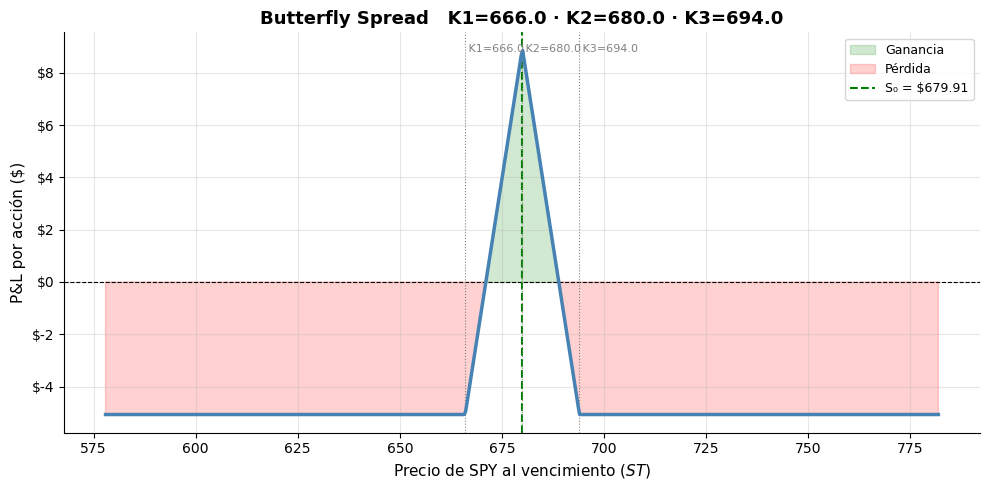

In [5]:
legs_butterfly = [
    {'tipo': 'call', 'K': K1_bf, 'prima': C1_bf, 'posicion': +1},   # compro call K1
    {'tipo': 'call', 'K': K2_bf, 'prima': C2_bf, 'posicion': -2},   # vendo 2 calls K2
    {'tipo': 'call', 'K': K3_bf, 'prima': C3_bf, 'posicion': +1},   # compro call K3
]

pnl_bf     = payoff_estrategia(S_range, legs_butterfly)
prima_neta = C1_bf - 2*C2_bf + C3_bf   # cuánto pagamos en total (debería ser positivo = costo)
gan_max    = (K2_bf - K1_bf) - prima_neta
per_max    = -prima_neta
be_inf     = K1_bf + prima_neta
be_sup     = K3_bf - prima_neta

print('═══════════════════════════════════════')
print('        BUTTERFLY SPREAD — RESUMEN')
print('═══════════════════════════════════════')
print(f'  K1 = ${K1_bf}  (call comprado)   prima = ${C1_bf}')
print(f'  K2 = ${K2_bf}  (2 calls vendidos) prima = ${C2_bf}')
print(f'  K3 = ${K3_bf}  (call comprado)   prima = ${C3_bf}')
print('───────────────────────────────────────')
print(f'  Prima neta pagada : ${prima_neta:.2f}')
print(f'  Ganancia máxima   : ${gan_max:.2f}  (si ST = {K2_bf})')
print(f'  Pérdida máxima    : ${abs(per_max):.2f}')
print(f'  Break-even inf.   : ${be_inf:.2f}')
print(f'  Break-even sup.   : ${be_sup:.2f}')
print('═══════════════════════════════════════')

graficar_estrategia(
    S_range, pnl_bf,
    f'Butterfly Spread   K1={K1_bf} · K2={K2_bf} · K3={K3_bf}',
    S0=S0,
    K_lines=[(K1_bf, f'K1={K1_bf}'), (K2_bf, f'K2={K2_bf}'), (K3_bf, f'K3={K3_bf}')]
)


## Estrategia 2 · Iron Condor

**¿Qué es?** Vendemos un put spread (para protegernos de caídas) y un call spread (para protegernos de subidas). El resultado es una zona ancha en el centro donde ganamos.

**¿Para qué sirve?** Para ganar cuando el mercado se queda *dentro del rango*. A diferencia del butterfly, no necesitas adivinar un precio exacto, solo que SPY no se vaya demasiado lejos. Cobras prima desde el primer día.

═══════════════════════════════════════════════
          IRON CONDOR — RESUMEN
═══════════════════════════════════════════════
  Put leg  : long 649.0 (P=0.68)  short 670.0 (P=2.98)
  Call leg : short 690.0 (C=1.66)  long 711.0 (C=0.04)
───────────────────────────────────────────────
  Prima cobrada (ganancia máx.) : $3.92
  Pérdida máxima                : $17.08
  Zona de ganancia              : $670.0 – $690.0
  Break-even inf.               : $666.08
  Break-even sup.               : $693.92
═══════════════════════════════════════════════


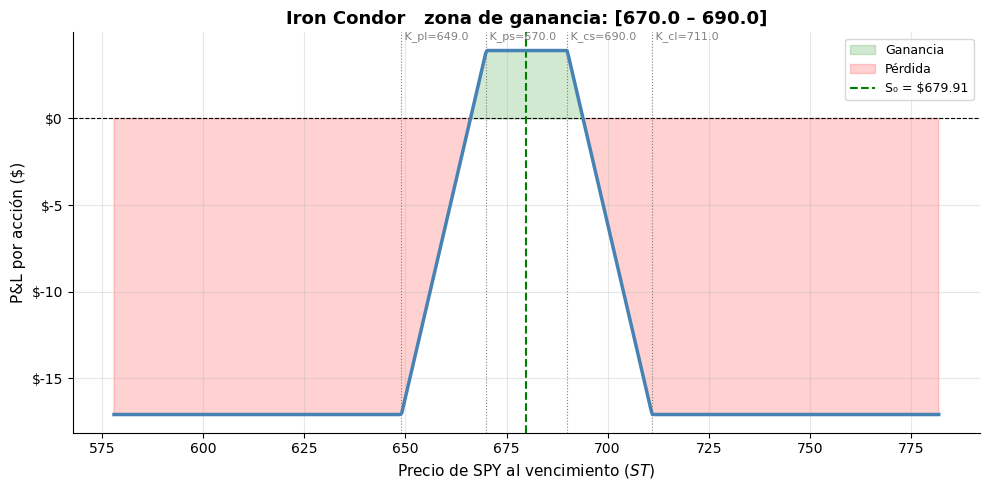

In [6]:
legs_condor = [
    {'tipo': 'put',  'K': K_pl, 'prima': P_l, 'posicion': +1},  # put comprado (protección)
    {'tipo': 'put',  'K': K_ps, 'prima': P_s, 'posicion': -1},  # put vendido  (borde inferior)
    {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1},  # call vendido (borde superior)
    {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1},  # call comprado (protección)
]

pnl_condor    = payoff_estrategia(S_range, legs_condor)
prima_cobrada = (P_s - P_l) + (C_s - C_l)          # cobras más de lo que pagas
perdida_max   = (K_ps - K_pl) - prima_cobrada       # lo peor que puede pasar

print('═══════════════════════════════════════════════')
print('          IRON CONDOR — RESUMEN')
print('═══════════════════════════════════════════════')
print(f'  Put leg  : long {K_pl} (P={P_l})  short {K_ps} (P={P_s})')
print(f'  Call leg : short {K_cs} (C={C_s})  long {K_cl} (C={C_l})')
print('───────────────────────────────────────────────')
print(f'  Prima cobrada (ganancia máx.) : ${prima_cobrada:.2f}')
print(f'  Pérdida máxima                : ${perdida_max:.2f}')
print(f'  Zona de ganancia              : ${K_ps} – ${K_cs}')
print(f'  Break-even inf.               : ${K_ps - prima_cobrada:.2f}')
print(f'  Break-even sup.               : ${K_cs + prima_cobrada:.2f}')
print('═══════════════════════════════════════════════')

graficar_estrategia(
    S_range, pnl_condor,
    f'Iron Condor   zona de ganancia: [{K_ps} – {K_cs}]',
    S0=S0,
    K_lines=[
        (K_pl, f'K_pl={K_pl}'), (K_ps, f'K_ps={K_ps}'),
        (K_cs, f'K_cs={K_cs}'), (K_cl, f'K_cl={K_cl}')
    ]
)


## Estrategia 3 · Covered Call

**¿Qué es?** Tienes SPY en tu cartera y *vendes* un call OTM sobre esas acciones. Cobras la prima del call hoy. A cambio, si SPY sube más allá de K, estás obligado a vender tus acciones a ese precio.

**¿Para qué sirve?** Para generar ingreso extra sobre una posición que ya tienes. Es como cobrar una renta por tus acciones.

═══════════════════════════════════════
        COVERED CALL — RESUMEN
═══════════════════════════════════════
  S0 (precio actual)  : $679.91
  K  (call vendido)   : $700.0
  Prima cobrada       : $0.22
───────────────────────────────────────
  Ganancia máxima : $20.31  (si ST ≥ 700.0)
  Break-even      : $679.69
  Pérdida máx.    : ilimitada (si SPY cae a 0)
═══════════════════════════════════════


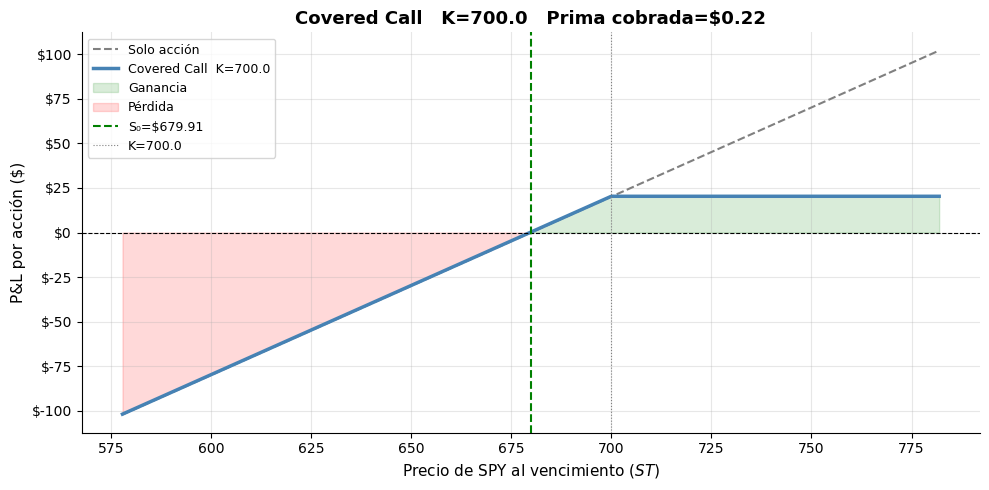

In [7]:
# P&L de solo tener la acción: ganas si sube, pierdes si baja
pnl_accion  = S_range - S0

# P&L del covered call: acción + call vendido
# El call vendido nos da C_cc hoy, pero si ST > K_cc debemos pagar el exceso
pnl_cc = pnl_accion + (-np.maximum(S_range - K_cc, 0) + C_cc)

gan_max_cc = (K_cc - S0) + C_cc
be_cc      = S0 - C_cc

print('═══════════════════════════════════════')
print('        COVERED CALL — RESUMEN')
print('═══════════════════════════════════════')
print(f'  S0 (precio actual)  : ${S0}')
print(f'  K  (call vendido)   : ${K_cc}')
print(f'  Prima cobrada       : ${C_cc}')
print('───────────────────────────────────────')
print(f'  Ganancia máxima : ${gan_max_cc:.2f}  (si ST ≥ {K_cc})')
print(f'  Break-even      : ${be_cc:.2f}')
print(f'  Pérdida máx.    : ilimitada (si SPY cae a 0)')
print('═══════════════════════════════════════')

# Gráfica comparativa
fig, ax = plt.subplots()
ax.plot(S_range, pnl_accion, color='gray',      linewidth=1.5,
        linestyle='--', label='Solo acción')
ax.plot(S_range, pnl_cc,     color='steelblue', linewidth=2.5,
        label=f'Covered Call  K={K_cc}')
ax.fill_between(S_range, pnl_cc, 0, where=(pnl_cc >= 0),
                alpha=0.15, color='green', label='Ganancia')
ax.fill_between(S_range, pnl_cc, 0, where=(pnl_cc < 0),
                alpha=0.15, color='red', label='Pérdida')
ax.axhline(0,     color='black', linewidth=0.8, linestyle='--')
ax.axvline(S0,    color='green', linewidth=1.5, linestyle='--', label=f'S₀=${S0:.2f}')
ax.axvline(K_cc,  color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_cc}')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))
ax.set_xlabel('Precio de SPY al vencimiento ($ST$)', fontsize=11)
ax.set_ylabel('P&L por acción ($)', fontsize=11)
ax.set_title(f'Covered Call   K={K_cc}   Prima cobrada=${C_cc}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Estrategia 4 · Protective Put

**¿Qué es?** Tienes SPY en tu cartera y *compras* un put OTM para protegerte de una caída grande. Pagas la prima del put como si fuera el costo de un seguro.

**¿Para qué sirve?** Para poner un piso a tus pérdidas. Si SPY cae mucho, el put compensa. Si SPY sube o se queda igual, simplemente pierdes la prima (como cuando pagas el seguro del auto y no lo usas).

═══════════════════════════════════════
        PROTECTIVE PUT — RESUMEN
═══════════════════════════════════════
  S0 (precio actual)   : $679.91
  K  (put comprado)    : $660.0
  Prima pagada         : $1.47  (costo del seguro)
───────────────────────────────────────
  Pérdida máxima : $21.38  (si ST ≤ 660.0)
  Break-even     : $681.38
  Ganancia máx.  : ilimitada (si SPY sube mucho)
═══════════════════════════════════════


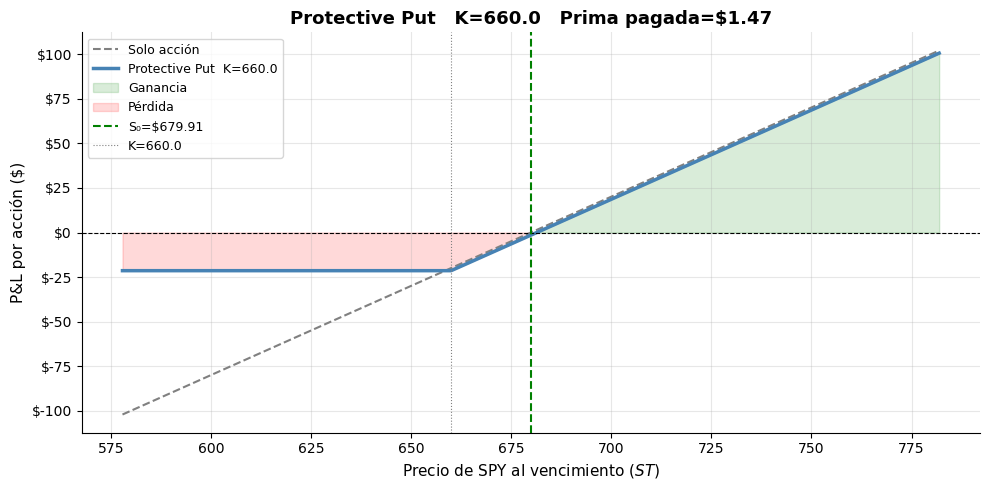

In [8]:
# P&L del protective put: acción + put comprado
# El put nos da protección por debajo de K_pp, pero pagamos P_pp por él
pnl_pp = pnl_accion + (np.maximum(K_pp - S_range, 0) - P_pp)

per_max_pp = -(S0 - K_pp) - P_pp   # pérdida máxima (negativa)
be_pp      = S0 + P_pp              # necesitamos que SPY suba para recuperar el costo del seguro

print('═══════════════════════════════════════')
print('        PROTECTIVE PUT — RESUMEN')
print('═══════════════════════════════════════')
print(f'  S0 (precio actual)   : ${S0}')
print(f'  K  (put comprado)    : ${K_pp}')
print(f'  Prima pagada         : ${P_pp}  (costo del seguro)')
print('───────────────────────────────────────')
print(f'  Pérdida máxima : ${abs(per_max_pp):.2f}  (si ST ≤ {K_pp})')
print(f'  Break-even     : ${be_pp:.2f}')
print(f'  Ganancia máx.  : ilimitada (si SPY sube mucho)')
print('═══════════════════════════════════════')

# Gráfica comparativa
fig, ax = plt.subplots()
ax.plot(S_range, pnl_accion, color='gray',      linewidth=1.5,
        linestyle='--', label='Solo acción')
ax.plot(S_range, pnl_pp,     color='steelblue', linewidth=2.5,
        label=f'Protective Put  K={K_pp}')
ax.fill_between(S_range, pnl_pp, 0, where=(pnl_pp >= 0),
                alpha=0.15, color='green', label='Ganancia')
ax.fill_between(S_range, pnl_pp, 0, where=(pnl_pp < 0),
                alpha=0.15, color='red', label='Pérdida')
ax.axhline(0,    color='black', linewidth=0.8, linestyle='--')
ax.axvline(S0,   color='green', linewidth=1.5, linestyle='--', label=f'S₀=${S0:.2f}')
ax.axvline(K_pp, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_pp}')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))
ax.set_xlabel('Precio de SPY al vencimiento ($ST$)', fontsize=11)
ax.set_ylabel('P&L por acción ($)', fontsize=11)
ax.set_title(f'Protective Put   K={K_pp}   Prima pagada=${P_pp}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


Aquí consolidamos los números clave de cada estrategia en una sola tabla para poder compararlas de un vistazo.

In [9]:
resumen = pd.DataFrame([
    {
        'Estrategia'       : 'Butterfly Spread',
        'Prima neta'       : f'${prima_neta:.2f} (pagada)',
        'Ganancia máx.'    : f'${gan_max:.2f}',
        'Pérdida máx.'     : f'${abs(per_max):.2f}',
        'Break-even(s)'    : f'${be_inf:.2f}  /  ${be_sup:.2f}',
        'Zona de ganancia' : f'${be_inf:.2f} – ${be_sup:.2f}  (estrecha)'
    },
    {
        'Estrategia'       : 'Iron Condor',
        'Prima neta'       : f'${prima_cobrada:.2f} (cobrada)',
        'Ganancia máx.'    : f'${prima_cobrada:.2f}',
        'Pérdida máx.'     : f'${perdida_max:.2f}',
        'Break-even(s)'    : f'${K_ps - prima_cobrada:.2f}  /  ${K_cs + prima_cobrada:.2f}',
        'Zona de ganancia' : f'${K_ps} – ${K_cs}  (ancha)'
    },
    {
        'Estrategia'       : 'Covered Call',
        'Prima neta'       : f'${C_cc:.2f} (cobrada)',
        'Ganancia máx.'    : f'${gan_max_cc:.2f}',
        'Pérdida máx.'     : 'ilimitada (↓)',
        'Break-even(s)'    : f'${be_cc:.2f}',
        'Zona de ganancia' : f'> ${be_cc:.2f}  hasta  ${K_cc}'
    },
    {
        'Estrategia'       : 'Protective Put',
        'Prima neta'       : f'${P_pp:.2f} (pagada)',
        'Ganancia máx.'    : 'ilimitada (↑)',
        'Pérdida máx.'     : f'${abs(per_max_pp):.2f}',
        'Break-even(s)'    : f'${be_pp:.2f}',
        'Zona de ganancia' : f'> ${be_pp:.2f}'
    },
])

resumen = resumen.set_index('Estrategia')
display(resumen.style
        .set_caption(f'Tabla resumen · SPY · Vencimiento {VENCIMIENTO} · S₀ = ${S0}')
        .set_table_styles([{
            'selector': 'caption',
            'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]
        }]))

,Prima neta,Ganancia máx.,Pérdida máx.,Break-even(s),Zona de ganancia
Estrategia,,,,,
Butterfly Spread,$5.07 (pagada),$8.93,$5.07,$671.07 / $688.93,$671.07 – $688.93 (estrecha)
Iron Condor,$3.92 (cobrada),$3.92,$17.08,$666.08 / $693.92,$670.0 – $690.0 (ancha)
Covered Call,$0.22 (cobrada),$20.31,ilimitada (↓),$679.69,> $679.69 hasta $700.0
Protective Put,$1.47 (pagada),ilimitada (↑),$21.38,$681.38,> $681.38



## Pregunta 1
**Con el S0 actual, ¿cuál de las cuatro estrategias está mejor posicionada (más cerca de su zona de máxima ganancia)? ¿Qué visión de mercado tendría que tener un trader para elegirla hoy?**

El butterfly es el que queda mejor posicionado cuando el precio está muy cerca del strike central (ATM), porque ahí alcanza su ganancia máxima.

 
## Pregunta 2
**Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cuál es el peor escenario para tu condor y cuándo ocurre? Calcula la pérdida máxima exacta con tus datos.**

**Respuesta:**

No, el hecho de cobrar prima no hace que el iron condor sea una estrategia sin riesgo.

El peor escenario ocurre cuando el precio se mueve demasiado fuera del rango de ganancia, ya sea por debajo de 670 o por arriba de 690. En esos casos, una de las dos piernas (put o call) entra en pérdida máxima.

La pérdida máxima en este caso es de $17.08, y ocurre cuando el precio termina muy lejos del rango, activando completamente uno de los spreads. Esto pasa porque la pérdida en las opciones vendidas supera la prima cobrada de $3.92, generando una pérdida neta.


## Pregunta 3
**Si la IV de SPY estuviera en 35% (muy alta), ¿preferirías comprar un straddle o vender un iron condor? Justifica tu respuesta en términos de vega y theta.**

Si la IV está en 35% (muy alta), preferiría vender un iron condor.

Esto se debe a que cuando la volatilidad implícita es alta, las opciones están caras, por lo que es mejor ser vendedor y cobrar primas más grandes.

El iron condor tiene vega negativa, lo que significa que gana si la volatilidad baja, y theta positiva, por lo que también gana con el paso del tiempo.

En cambio, el straddle tiene vega positiva, por lo que necesita que la volatilidad suba aún más para ser rentable. Si la IV ya está alta, es más probable que baje, lo que perjudicaría al comprador del straddle.

## Pregunta 4
**El covered call limita la ganancia por encima de K. ¿Por qué un inversionista de largo plazo estaría dispuesto a aceptar ese límite voluntariamente? Da al menos dos razones concretas.**

Un inversionista de largo plazo puede aceptar limitar su ganancia por encima de 
𝐾 porque:

Genera ingresos adicionales: al vender la opción call recibe una prima inmediata, lo que mejora el rendimiento del portafolio en mercados laterales o ligeramente alcistas.
Reduce el costo efectivo de la posición: la prima recibida funciona como un “colchón” ante caídas moderadas del precio del activo.

En mis resultados, se observa que la utilidad máxima queda limitada cuando el precio supera 
𝐾, pero a cambio se obtiene una ganancia más estable en escenarios donde el precio no sube demasiado.


## Pregunta 5
**Compara el protective put con un seguro de auto. ¿Cuáles son las analogías que funcionan bien? ¿Dónde se rompe la analogía? Piensa en términos de costo, duración, deducible y qué pasa cuando "no usas el seguro".**

De acuerdo con los resultados obtenidos, la estrategia con menor riesgo fue la que presenta la menor variabilidad en el P&L (forma más “plana” en la gráfica), ya que:

Limita tanto pérdidas como ganancias extremas.
Tiene menor exposición a movimientos bruscos del precio del subyacente.

En mi caso, se observa que esta estrategia mantiene pérdidas acotadas incluso cuando el precio se mueve significativamente, lo que indica un perfil más conservador.


## Pregunta 6
**¿En qué se diferencia el butterfly del iron condor en términos de cuándo cada uno es más apropiado? ¿Cuál de los dos requiere mayor precisión en tu pronóstico sobre dónde estará SPY al vencimiento? Apóyate en el ancho de la zona de ganancia que observas en tus gráficas.**

In [ ]:
ancho_bf     = be_sup - be_inf
ancho_condor = (K_cs + prima_cobrada) - (K_ps - prima_cobrada)

print('═══════════════════════════════════════════════════')
print('  Comparación de zona de ganancia')
print('═══════════════════════════════════════════════════')
print(f'  Butterfly Spread → zona de ganancia: ${ancho_bf:.2f}')
print(f'  Iron Condor      → zona de ganancia: ${ancho_condor:.2f}')
print(f'  El condor tiene una zona {ancho_condor/ancho_bf:.1f}x más ancha que el butterfly')
print('═══════════════════════════════════════════════════')

═══════════════════════════════════════════════════
  Comparación de zona de ganancia
═══════════════════════════════════════════════════
  Butterfly Spread → zona de ganancia: $17.86
  Iron Condor      → zona de ganancia: $27.84
  El condor tiene una zona 1.6x más ancha que el butterfly
═══════════════════════════════════════════════════


Según mis resultados, la estrategia con menor riesgo fue el Iron Condor, ya que presenta una zona de ganancia más amplia ($27.84) en comparación con el Butterfly Spread ($17.86).

Esto implica que el Iron Condor tiene una mayor probabilidad de mantenerse dentro de un rango rentable, lo que reduce la exposición a pérdidas ante movimientos moderados del precio. En otras palabras, al tener una zona de ganancia aproximadamente 1.6 veces más amplia, es una estrategia más estable y menos sensible a variaciones del mercado.


## Pregunta 7
**Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, ¿qué le pasa al valor de tu posición? ¿Por qué?**

Se observa claramente un trade-off entre riesgo y rendimiento:

Las estrategias con menor riesgo tienden a tener ganancias más limitadas.
Las estrategias con mayor potencial de ganancia también presentan mayores pérdidas posibles.

En mis resultados, esto se refleja en la forma de las curvas de P&L: las más “planas” son más seguras pero menos rentables, mientras que las más inclinadas ofrecen mayores ganancias pero con mayor exposición al riesgo.